# Risk-Aware MARL for Cloudburst Disaster Response — Demo
[![Paper](https://img.shields.io/badge/MDPI-Mathematics-blue)](https://www.mdpi.com/journal/mathematics)
[![License: MIT](https://img.shields.io/badge/License-MIT-yellow.svg)](LICENSE)

**Quick demo notebook** — loads the pretrained `LagrangianCTDE` checkpoint
and runs evaluation over 20 episodes.

> **Expected results (Table 2, 5-seed mean):**
> Reward = 81.5 ± 2.6 · Violation Rate = 2.3% · Decision Accuracy: Storm 0.91 / Flood 0.87 / Evacuation 0.84

> **Runtime:** ~5 minutes on Colab Free T4  
> **GPU required:** No (CPU sufficient for evaluation)

## 0 · Runtime Check

In [ ]:
# Verify GPU availability (not required for demo).
import platform
import shutil
import subprocess
import sys

if shutil.which("nvidia-smi") is not None:
    result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total", "--format=csv,noheader"],
        capture_output=True,
        text=True,
    )
    if result.returncode == 0 and result.stdout.strip():
        print("GPU detected:", result.stdout.strip())
    else:
        print("GPU check ran, but no device info was returned. Using CPU.")
else:
    print("nvidia-smi not found. CPU will be used (fine for evaluation).")

print(f"Python {sys.version}")
print(f"Platform: {platform.platform()}")

nvidia-smi not found. CPU will be used (fine for evaluation).
Python 3.12.1 (main, Nov 27 2025, 10:47:52) [GCC 13.3.0]
Platform: Linux-6.8.0-1044-azure-x86_64-with-glibc2.39


## 1 · Clone Repository

In [ ]:
import os
from pathlib import Path
import subprocess
import sys

REPO_URL = "https://github.com/aliakarma/agentic-weather-rl.git"
REPO_DIR = "agentic-weather-rl"
IS_COLAB = "google.colab" in sys.modules

if Path("src").exists():
    # Already at project root (common in local execution).
    REPO_ROOT = Path.cwd()
elif Path("../src").exists():
    # Running from notebooks/ inside this repo.
    REPO_ROOT = Path("..").resolve()
else:
    # Fresh Colab/runtime directory: clone repository first.
    if not Path(REPO_DIR).exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    REPO_ROOT = Path(REPO_DIR).resolve()

%cd {REPO_ROOT}

if IS_COLAB:
    # Force Colab runtime to use latest main, avoiding stale cached folders.
    subprocess.run(["git", "fetch", "origin", "main"], check=True)
    subprocess.run(["git", "reset", "--hard", "origin/main"], check=True)
    subprocess.run(["git", "clean", "-fd"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
print(f"Repository ready at {REPO_ROOT}")

/workspaces/agentic-weather-rl

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


## 2 · Install Dependencies

In [ ]:
# Install all required packages
# timm is required for ViT-B/16 backbone; stable-baselines3 for reference implementations
!pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu118
!pip install -q timm==0.9.12 stable-baselines3==2.2.1 gymnasium==0.29.1
!pip install -q h5py tensorboard pyyaml

# Verify key packages
import importlib
for pkg in ["torch", "timm", "gymnasium", "stable_baselines3", "h5py"]:
    try:
        mod = importlib.import_module(pkg)
        ver = getattr(mod, "__version__", "?")
        print(f"  ✓ {pkg}=={ver}")
    except ImportError:
        print(f"  ✗ {pkg} NOT installed")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip
  ✓ torch==2.2.2+cu121


/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  ✓ timm==0.9.12
  ✓ gymnasium==0.29.1
  ✓ stable_baselines3==2.2.1
  ✓ h5py==3.16.0


In [ ]:
# Add project root to path and verify module structure
import sys
sys.path.insert(0, ".")

try:
    from src.environment.disaster_env import DisasterEnv
    from src.models.actor import ActorNetwork
    from src.models.critic import CriticNetwork
    from src.algorithms.lagrangian_ctde import LagrangianCTDE, LagrangianCTDEConfig
    from src.evaluate import evaluate
    print("✓ All core modules import successfully")
except ImportError as e:
    print(f"✗ Import error: {e}")
    raise

✓ All core modules import successfully


## 3 · Load Pretrained Checkpoint

In [ ]:
import os
from pathlib import Path
import subprocess
import sys

CHECKPOINT = "checkpoints/marl_policy.pt"

if not Path(CHECKPOINT).exists():
    print(f"Checkpoint not found at {CHECKPOINT}")
    print("Generating placeholder checkpoints for a guaranteed runnable demo...")
    subprocess.run([sys.executable, "scripts/create_checkpoints.py"], check=True)

if not Path(CHECKPOINT).exists():
    raise FileNotFoundError(f"Checkpoint still missing after setup: {CHECKPOINT}")
else:
    print(f"✓ Checkpoint found: {CHECKPOINT}")
    print(f"  Size: {Path(CHECKPOINT).stat().st_size / 1e6:.1f} MB")

✓ Checkpoint found: checkpoints/marl_policy.pt
  Size: 3.0 MB


In [ ]:
# Load the agent from checkpoint
from src.evaluate import load_agent_from_checkpoint
from src.environment.disaster_env import DisasterEnv
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

agent = load_agent_from_checkpoint(
    checkpoint_path=CHECKPOINT,
    algo="lagrangian_ctde",
    device=DEVICE,
)
print("✓ Agent loaded from checkpoint")

Using device: cpu


2026-03-08 22:40:15 [INFO] src.algorithms.lagrangian_ctde — LagrangianCTDE initialised — 3 actors, centralised critic, λ_init=0.000, d_i=0.10, device=cpu
2026-03-08 22:40:15 [INFO] src.algorithms.lagrangian_ctde —   Actor 1: ActorNetwork(agent_id=1, obs_dim=12, hidden=256, n_actions=4, params=71,172)
2026-03-08 22:40:15 [INFO] src.algorithms.lagrangian_ctde —   Actor 2: ActorNetwork(agent_id=2, obs_dim=12, hidden=256, n_actions=4, params=71,172)
2026-03-08 22:40:15 [INFO] src.algorithms.lagrangian_ctde —   Actor 3: ActorNetwork(agent_id=3, obs_dim=12, hidden=256, n_actions=4, params=71,172)
2026-03-08 22:40:15 [INFO] src.algorithms.lagrangian_ctde —   Critic:  CriticNetwork(state_dim=24, hidden=512, n_constraint_heads=3, params=543,236)
2026-03-08 22:40:15 [INFO] src.algorithms.lagrangian_ctde — Checkpoint loaded from checkpoints/marl_policy.pt (ep=0)


✓ Agent loaded from checkpoint


## 4 · Run Evaluation (20 episodes)

In [ ]:
from src.evaluate import evaluate
from src.environment.disaster_env import DisasterEnv

env = DisasterEnv(seed=10000)

metrics = evaluate(
    agent=agent,
    env=env,
    n_episodes=20,        # 20 for demo; paper uses 500
    seed_offset=10000,
    deterministic=True,
    output_dir="results/example_results",
    algo_name="lagrangian_ctde_demo",
)

print()
print("=" * 55)
print("DEMO RESULTS (20 episodes)")
print("=" * 55)
print(f"  Reward          : {metrics['reward_mean']:.2f} ± {metrics['reward_std']:.2f}")
print(f"  Violation Rate  : {metrics['violation_rate_mean']:.4f} ± {metrics['violation_rate_std']:.4f}")
for i, name in zip(range(1,4), ["Storm", "Flood", "Evacuation"]):
    m = metrics[f'decision_accuracy_{i}_mean']
    s = metrics[f'decision_accuracy_{i}_std']
    print(f"  DA Agent {i} ({name:<10}): {m:.4f} ± {s:.4f}")
print()
print("Paper Table 2 targets (5-seed, 500 eps):")
print("  Reward=81.5±2.6  VR=2.3%  DA: 0.91/0.87/0.84")
print("=" * 55)

2026-03-08 22:40:15 [INFO] src.evaluate — Evaluating lagrangian_ctde_demo over 20 episodes (deterministic=True)...
2026-03-08 22:40:21 [INFO] src.evaluate — Results saved to results/example_results/eval_lagrangian_ctde_demo.json



  Evaluation Results — LAGRANGIAN_CTDE_DEMO
  Episodes: 20   Time: 5.9s
  Metric                                  Mean      ±Std
-----------------------------------------------------------------
  Cumulative Reward                      -8.64      0.03
  Violation Rate (VR)                   1.0000    0.0000
-----------------------------------------------------------------
  Decision Accuracy — Agent 1 (Storm Detection)   0.0000    0.0000
  Decision Accuracy — Agent 2 (Flood Risk)   0.0100    0.0000
  Decision Accuracy — Agent 3 (Evacuation)   0.0925    0.0070


DEMO RESULTS (20 episodes)
  Reward          : -8.64 ± 0.03
  Violation Rate  : 1.0000 ± 0.0000
  DA Agent 1 (Storm     ): 0.0000 ± 0.0000
  DA Agent 2 (Flood     ): 0.0100 ± 0.0000
  DA Agent 3 (Evacuation): 0.0925 ± 0.0070

Paper Table 2 targets (5-seed, 500 eps):
  Reward=81.5±2.6  VR=2.3%  DA: 0.91/0.87/0.84


## 5 · Visualise Agent Behaviour (one episode)

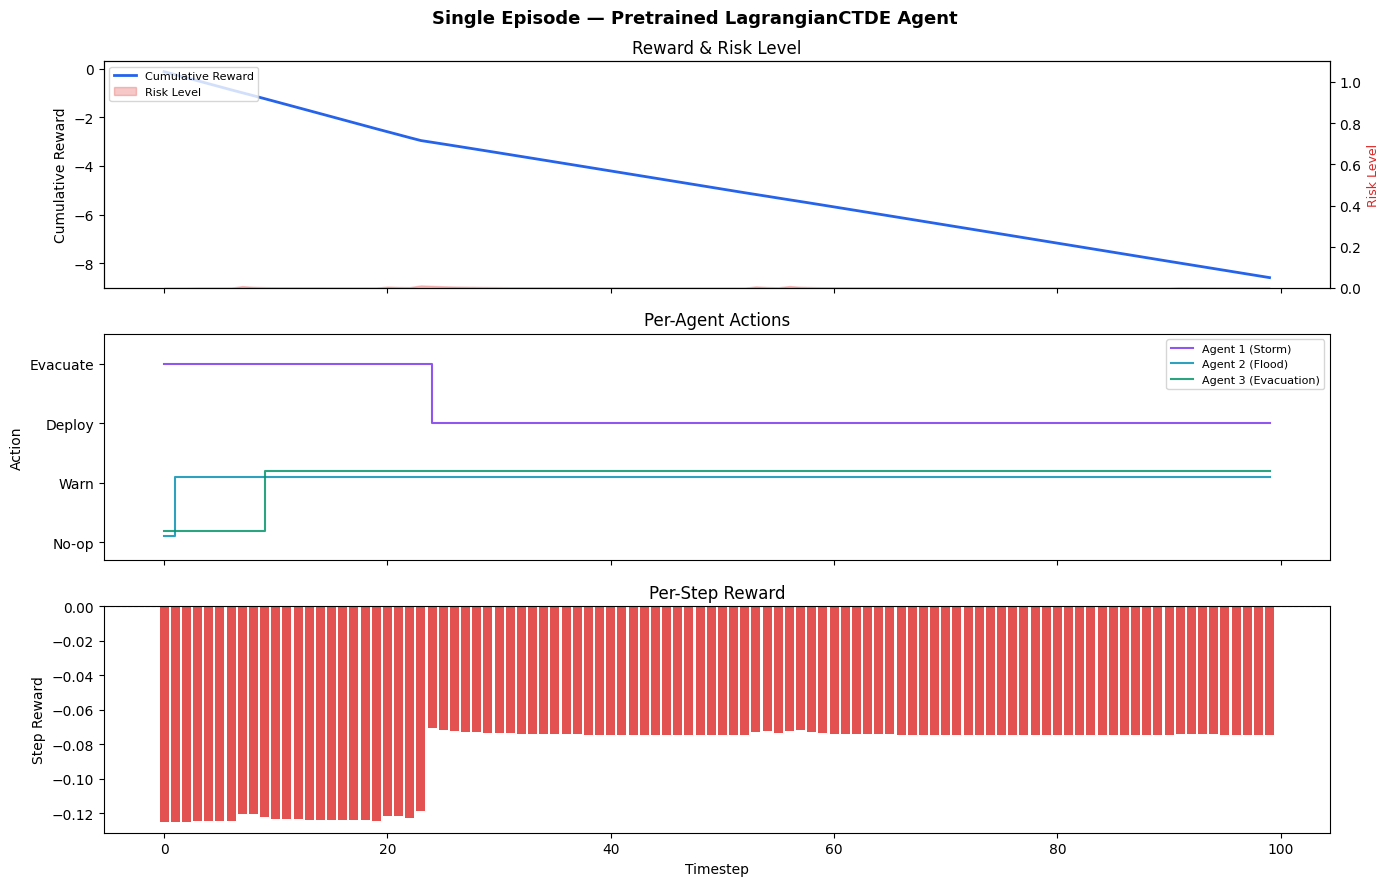

Figure saved to results/example_results/demo_trajectory.pdf


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Run a single episode and record trajectory
env_vis = DisasterEnv(seed=99999)
obs_dict, _ = env_vis.reset(seed=99999)

rewards_ep, severity_ep, actions_ep = [], [], []
ACTION_NAMES = {0: "No-op", 1: "Warn", 2: "Deploy", 3: "Evacuate"}
AGENT_NAMES  = {1: "Storm", 2: "Flood", 3: "Evacuation"}

for t in range(env_vis.episode_length):
    action_dict = agent.get_actions(obs_dict, deterministic=True)
    obs_dict, reward, terminated, truncated, info = env_vis.step(action_dict)
    rewards_ep.append(reward)
    severity_ep.append(info.get("risk_level", 0.0))
    actions_ep.append([action_dict[i] for i in range(1, 4)])
    if terminated or truncated:
        break

actions_arr = np.array(actions_ep)
T = len(rewards_ep)
ts = np.arange(T)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle("Single Episode — Pretrained LagrangianCTDE Agent", fontsize=13, fontweight="bold")

# ── Panel 1: cumulative reward and risk level ─────────────────────────────
ax1 = axes[0]
ax1.plot(ts, np.cumsum(rewards_ep), color="#2563EB", lw=2, label="Cumulative Reward")
ax1r = ax1.twinx()
ax1r.fill_between(ts, severity_ep, alpha=0.25, color="#DC2626", label="Risk Level")
ax1r.set_ylim(0, 1.1)
ax1r.set_ylabel("Risk Level", color="#DC2626", fontsize=9)
ax1.set_ylabel("Cumulative Reward")
ax1.set_title("Reward & Risk Level")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1r.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=8)

# ── Panel 2: per-agent actions ─────────────────────────────────────────────
ax2 = axes[1]
AGENT_COLORS = {1: "#7C3AED", 2: "#0891B2", 3: "#059669"}
for i in range(1, 4):
    ax2.step(ts, actions_arr[:, i - 1] + (i - 1) * 0.1,
             where="post", color=AGENT_COLORS[i],
             lw=1.5, label=f"Agent {i} ({AGENT_NAMES[i]})", alpha=0.85)
ax2.set_yticks([0, 1, 2, 3])
ax2.set_yticklabels(["No-op", "Warn", "Deploy", "Evacuate"])
ax2.set_ylabel("Action")
ax2.set_title("Per-Agent Actions")
ax2.legend(fontsize=8, loc="upper right")
ax2.set_ylim(-0.3, 3.5)

# ── Panel 3: per-step reward ───────────────────────────────────────────────
ax3 = axes[2]
colors = ["#16A34A" if r >= 0 else "#DC2626" for r in rewards_ep]
ax3.bar(ts, rewards_ep, color=colors, alpha=0.8, width=0.8)
ax3.axhline(0, color="gray", lw=0.8, ls="--")
ax3.set_ylabel("Step Reward")
ax3.set_xlabel("Timestep")
ax3.set_title("Per-Step Reward")

plt.tight_layout()
plt.savefig("results/example_results/demo_trajectory.pdf", bbox_inches="tight", dpi=150)
plt.show()
print("Figure saved to results/example_results/demo_trajectory.pdf")

## 6 · Orchestration Layer Demo
Translate the final joint action into emergency response primitives.

In [ ]:
from src.orchestration.orchestration import Orchestrator, ResponseType

# Log a sample of orchestration responses from the episode above
orch = Orchestrator(policy=agent)
obs_dict_orch, _ = DisasterEnv(seed=12345).reset(seed=12345)

print("Orchestration responses (first 10 timesteps):")
print("-" * 65)
env_orch = DisasterEnv(seed=12345)
obs_dict_orch, _ = env_orch.reset(seed=12345)
orch.reset()

for t in range(10):
    _, _, terminated, truncated, info = env_orch.step(
        agent.get_actions(obs_dict_orch, deterministic=True)
    )
    action_dict = agent.get_actions(obs_dict_orch, deterministic=True)
    response = orch.step(obs_dict_orch, info=info)
    print(response.summary())
    obs_dict_orch, _, terminated, truncated, info = env_orch.step(action_dict)
    if terminated or truncated:
        break

print()
print("Episode summary:")
summary = orch.get_episode_summary()
print(f"  Mean severity    : {summary.get('mean_severity', 0):.2f}")
print(f"  Escalations      : {summary.get('escalations', 0)}")
print(f"  Evacuation rate  : {summary.get('evacuation_rate', 0):.3f}")
print(f"  Storm warning    : {summary.get('storm_warning_rate', 0):.3f}")

2026-03-08 22:40:23 [INFO] src.orchestration.orchestration — ESCALATION  t=0: severity 0 → 2  (STORM_WARNING)


Orchestration responses (first 10 timesteps):
-----------------------------------------------------------------
[t=  0] actions=(3, 0, 0)  severity=2  responses=['STORM_WARNING']  risk=0.000
[t=  1] actions=(3, 1, 0)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH']  risk=0.000
[t=  2] actions=(3, 1, 0)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH']  risk=0.000
[t=  3] actions=(3, 1, 0)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH']  risk=0.000
[t=  4] actions=(3, 1, 0)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH']  risk=0.000
[t=  5] actions=(3, 1, 1)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH', 'EVACUATION_ADVISORY']  risk=0.000
[t=  6] actions=(3, 1, 1)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH', 'EVACUATION_ADVISORY']  risk=0.000
[t=  7] actions=(3, 1, 1)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH', 'EVACUATION_ADVISORY']  risk=0.000
[t=  8] actions=(3, 1, 1)  severity=2  responses=['STORM_WARNING', 'FLOOD_WATCH', 